# Gibbs Sampling with a Slice-Sampled Full Conditional

Uses `mcmc_algorithms.algorithms.slice_sampler` both as a standalone 1D sampler and as the inner full-conditional sampler for a Gibbs sweep over an AR(1) stochastic volatility model (`gibbs_sv_sampler`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

from mcmc_algorithms.algorithms import slice_sampler, target, gibbs_sv_sampler

FIGURES_DIR = Path("../figures")

## 1D slice sampler on a standard normal

`slice_sampler` always calls `target(x, alpha, rho)`; for targets that don't need those extra parameters, wrap them so the extra arguments are simply ignored.

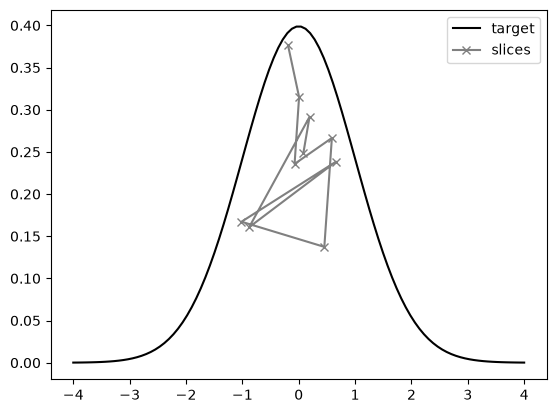

In [10]:
target_std_normal = lambda x, alpha, rho: stats.norm.pdf(x)
x_vals, y_vals = slice_sampler(target_std_normal, 0, 0, 1, 10, 0)

fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-4, 4, 100)

plt.plot(x, stats.norm.pdf(x), 'k-', label='target')
plt.plot(x_vals, y_vals, 'x-', color='gray', label='slices')
plt.legend()

## Slice sampler on the custom `target(x, alpha, rho)` density

`target` is the full-conditional density (up to a normalizing constant) used throughout this notebook; `alpha=5, rho=1` matches the example used in the thesis.

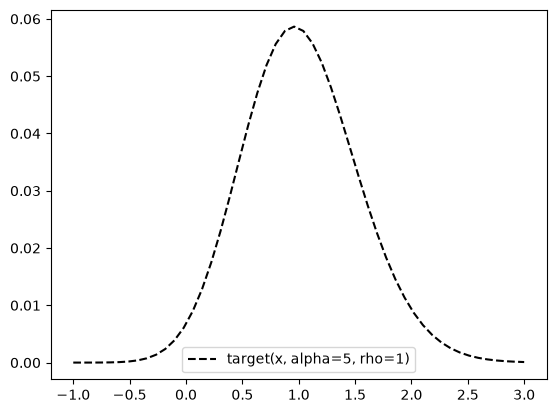

In [11]:
fig, ax = plt.subplots(1, 1)
x = np.linspace(-1, 3, 50)
plt.plot(x, target(x, 5, 1), 'k--', label='target(x, alpha=5, rho=1)')
plt.legend()

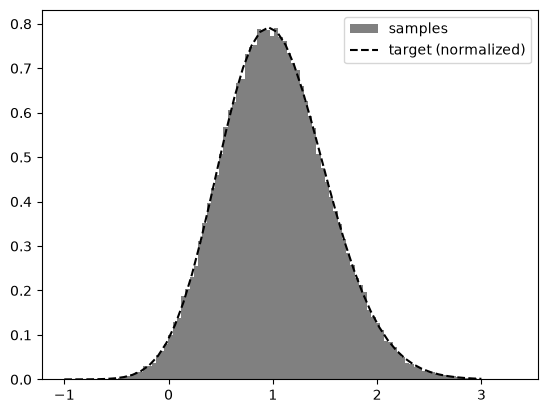

In [12]:
x_vals, y_vals = slice_sampler(target, 5, 1, 1, 100000, 1)

fig, ax_ = plt.subplots(1, 1)
plt.hist(x_vals, bins=100, density=True, label="samples", color='gray')
plt.plot(x, target(x, 5, 1) / np.trapezoid(target(x, 5, 1), x), 'k--', label='target (normalized)')
plt.legend()

## Gibbs sampling an AR(1) stochastic volatility model

`gibbs_sv_sampler` sweeps over `n + 1` latent log-volatility states `x_0, ..., x_n`. At each sweep, every state's full conditional (parameterized by `mu`, `alpha`, `rho`, derived from the AR(1) transition and the observation likelihood) is sampled with `slice_sampler`, and the state is updated to the mode of those draws.

In [13]:
n = 20
iterations = 20
sampler_iterations = 2000
w = 1

phi = 0.98
sigma = 0.14
beta = 0.66
log_y_vec = np.array([-0.2, -2, 0, -0.1, -1.8, 0.3, -1.7, -1.6, -6, 1.2, 2.2,
                      -7.9, 0.2, 0.05, 2.3, -1, 1.3, 0.7, 1.3, 2, 1.4])
y_vec = np.sqrt(np.exp(log_y_vec)) * beta

x_history, pi_hist = gibbs_sv_sampler(y_vec, phi, sigma, beta, w, iterations, sampler_iterations)
print(x_history[-1])

100%|██████████| 20/20 [00:13<00:00,  1.43it/s]

[ 0.04852277  0.01243119  0.02551324 -0.02400898 -0.01471796  0.01568097
  0.00071398  0.0038958   0.02873308  0.00156844  0.03587485 -0.0012559
 -0.00409932 -0.00147266  0.04979416  0.0128276   0.01329618  0.05398697
  0.0196484   0.00452802  0.05928369]


### Convergence of the sampled states across sweeps

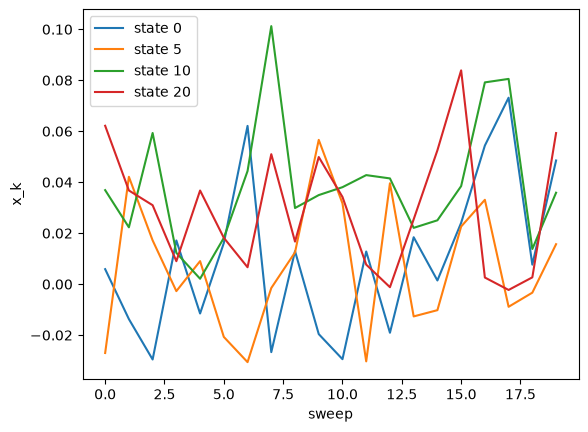

In [14]:
fig, ax = plt.subplots(1, 1)
for k in [0, 5, 10, 20]:
    ax.plot(x_history[:, k], label=f"state {k}")
ax.set_xlabel("sweep")
ax.set_ylabel("x_k")
plt.legend()

### Full-conditional draws for selected states (last sweep)

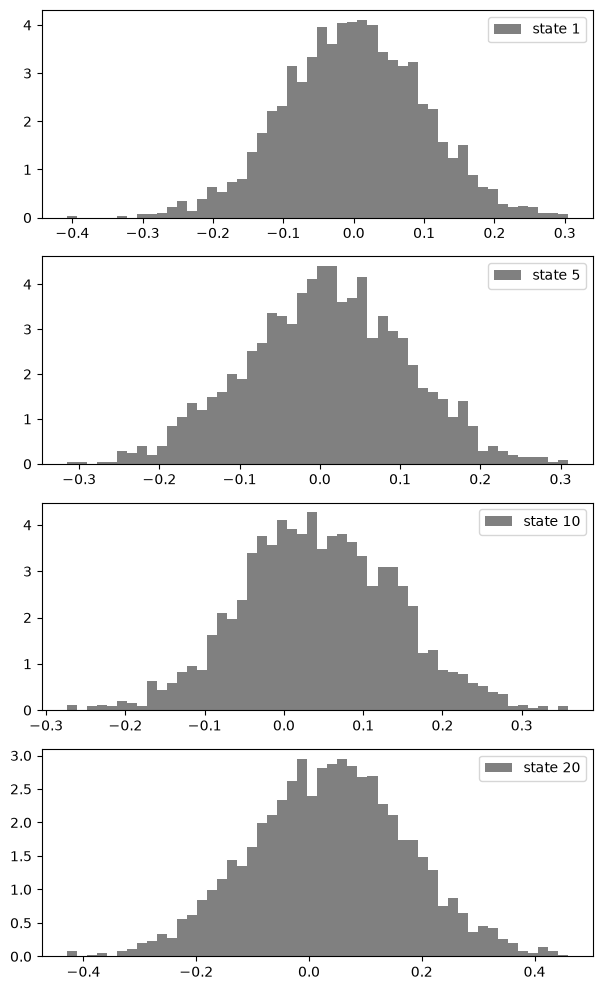

In [15]:
fig, ax = plt.subplots(4, 1, figsize=(6, 10))
for axis, k in zip(ax, [1, 5, 10, 20]):
    axis.hist(pi_hist[k], bins=50, density=True, label=f"state {k}", color='grey')
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "gibbs_sv_full_conditionals.png", dpi=150, bbox_inches="tight")